# Mining Association Rules

## Introduction

This notebook applies an interpretable rule-mining method to recover the aggregation logic used by Community Notes when converting individual ratings into final “helpful” or “not helpful” decisions. Although logistic regression is traditionally taught as a supervised learning model, recent work in data mining treats it as a powerful tool for extracting stable, human-interpretable decision rules from large-scale behavioral datasets. In this assignment, I use logistic regression not for prediction, but to identify the implicit aggregation boundary the platform appears to apply when deciding whether a note becomes visible.

This method is well-suited to Community Notes because the underlying decision rule is not publicly documented and must be inferred from millions of historical rating events. By estimating how changes in the fraction of helpful ratings, not-helpful ratings, and rating volume alter the log-odds of a note being marked helpful, the model recovers the platform’s structural behavior under typical rating conditions. Extending the model with topic-level indicator effects allows me to test a central question of my larger project: Is the aggregation rule consistent across content domains, or are some topics effectively held to stricter standards?

The goal of this notebook is not to build a predictive classifier, but to develop an interpretable, scalable procedure for mining the approximate “decision boundary” that governs system behavior. This boundary becomes the baseline for evaluating aggregation consistency, one of the core dimensions of collective-intelligence quality in Community Notes. Using this rule-mining approach provides a transparent and replicable way to characterize how the system aggregates crowd input at scale.


## Literature Review

A few researchers use logistic regression and association-rule mining to extract interpretable behavioral rules from large datasets. Although their application domains differ, these studies share a core motivation with my project: using transparent statistical techniques to recover implicit decision structures in complex sociotechnical systems.

One line of work demonstrates how logistic regression scales as a rule-extraction tool in massive behavioral datasets. Jain et al. (2020) apply logistic regression to telecommunication customer records to identify the behavioral and demographic factors most strongly associated with churn. Their emphasis is not on building the most predictive model but on using coefficient structure to reveal underlying decision patterns—a framing that parallels my use of logistic regression as a tool for recovering the aggregation rule in Community Notes rather than as a high-performance classifier.

A second strand of literature explicitly combines logistic regression with association-rule mining to extract structured, human-readable rules in noisy environments. Shahin et al. (2024) propose a hybrid logistic-regression + Apriori framework that first identifies statistically significant predictors using logistic regression, then quantifies co-occurrence patterns among those influential variables using association-rule mining. This layered approach enables interpretable rule extraction even in systems where outcomes depend on many interacting features, which closely resembles the multi-rater evaluation structure in Community Notes.

Finally, large-scale association-rule mining applications demonstrate the feasibility of mining stable rules from millions of high-dimensional observations. For example, He et al. (2025) use platform-governance data from Reddit to analyze how algorithm-based moderation structures user behavior. Although their rules are not derived through logistic regression, the study illustrates a key idea relevant to my work: rule mining becomes most informative when applied to vast datasets where human evaluators cannot manually infer the underlying decision logics.

Taken together, this literature supports the methodological approach I adopt in this notebook. These studies show that (1) logistic models scale well to large behavioral datasets, (2) logistic coefficients offer transparent summaries of decision structures, and (3) association-rule frameworks can reveal systematic variation across contexts—in my case, across the different content domains represented in Community Notes.


## Applying the Method to Community Notes: Experiments and Iteration

The first step was to construct a per-note feature table that captures the inputs the platform seems to use when producing final helpfulness decisions. Using Spark, I aggregated all ratings for each note to compute (1) the fraction marked helpful, (2) the fraction marked not-helpful, and (3) the total number of ratings. I then joined these with the topic labels derived in earlier notebooks and the platform’s recorded final outcomes. This produced a unified table of roughly one million notes with complete rating and topic information.

Before fitting the model, I conducted alignment checks to ensure consistency across `ratings`, `notes`, `topics`, and `status` tables. These checks revealed that only ~1.33M notes ever received usable topic labels, and this subset aligned cleanly with rating history. I filtered the modeling sample to notes with at least five ratings to avoid unstable fractions and added a log-transformed volume term `(log10(n_ratings))`, which improved model stability and allowed me to evaluate whether the apparent decision boundary shifts as rating volume increases

I implemented the logistic regression through a Spark ML pipeline with one-hot–encoded meta-topic indicators. The feature vector consisted of `frac_helpful`, `frac_notHelpful`, `log_n_ratings`, and the topic dummies. The goal was not predictive performance but understanding how the fitted coefficients reconstruct the system’s aggregation structure.

Scaling the method on Midway required configuring executor memory (48–60 GB) and testing pipeline latency across partitions. Aggregation, joining, and grouping operations all scaled cleanly. The main bottleneck occurred when visualizing topic-specific logistic curves, which required computing thousands of predicted probabilities. I optimized this step by vectorizing the computation and fixing rating volume at the median value.

I refined the modeling setup through several checks. Notes with very few ratings produced unstable helpfulness fractions, so I imposed a minimum threshold of five ratings per note to ensure that the aggregation inputs reflected meaningful crowd feedback. I also added a log-transformed rating-volume term, which improved coefficient stability and allowed me to examine whether the apparent decision boundary varies with scale. Including topic-level intercept shifts enabled the model to capture systematic differences across content domains without altering the functional form of the aggregation rule. These adjustments produced a stable, interpretable specification that cleanly recovers the platform’s implicit decision boundary while remaining faithful to the observed behavior of the system.

In [2]:
# ================================================================
# AGGREGATION MODELING — Logistic Regression to Recover Decision Rule
# ================================================================

import os
import sys
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import FloatType, IntegerType

# Spark initialization (RCC compute node)
try:
    spark.stop()
except:
    pass

spark = (
    SparkSession.builder
        .appName("aggregation_modeling_logit")
        .config("spark.driver.memory", "48g")
        .config("spark.executor.memory", "48g")
        .config("spark.sql.shuffle.partitions", "400")
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
        .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark session initialized.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/07 18:42:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session initialized.


In [3]:
# ============================================================
# Loading ratings, notes, topics, and status tables
# ============================================================

PROJECT_ROOT = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe"
DATA_DIR     = f"{PROJECT_ROOT}/data"

RATINGS_PATH = f"{DATA_DIR}/interim/ratings_parquet/ratings.parquet"
NOTES_PATH   = f"{DATA_DIR}/interim/processed/notes.parquet"     
TOPICS_PATH  = f"{DATA_DIR}/interim/outputs/notes_topics_labeled_with_labels.parquet"
STATUS_PATH  = f"{DATA_DIR}/interim/processed/noteStatusHistory.parquet"

ratings = spark.read.parquet(RATINGS_PATH)
notes   = spark.read.parquet(NOTES_PATH)    
topics_notes  = spark.read.parquet(TOPICS_PATH)
status  = spark.read.parquet(STATUS_PATH)

print("Loaded:")
print("  ratings:", ratings.count())
print("  notes:", notes.count())
print("  topics:", topics_notes.count())
print("  status:", status.count())


Loaded:


  ratings: 171721201
  notes: 2119356
  topics: 1329043
  status: 2284533


For reference, Only notes with usable English text summaries (non-null, long enough, passed cleaning + language detection) were eligible for SBERT + clustering, so only that ≈1.33M-note subset ever received topic labels; the remaining ≈0.8M notes lacked usable summary text or were filtered out earlier.

In [4]:
# ============================================================
# I conduct Validation Checks: Alignment Across Notes / Topics / Ratings
# ============================================================

print("\n========= DISTINCT noteId COUNTS =========")

notes_count        = notes.select("noteId").distinct().count()
topics_count       = topics_notes.select("noteId").distinct().count()
ratings_notes      = ratings.select("noteId").distinct().count()
status_notes       = status.select("noteId").distinct().count()

print(f"All notes (notes):                     {notes_count:,}")
print(f"Notes with topic labels (topics_notes): {topics_count:,}")
print(f"Notes appearing in ratings:            {ratings_notes:,}")
print(f"Notes with status history:             {status_notes:,}")


# ============================================================
# Quick Coverage Checks
# ============================================================

print("\n========= COVERAGE CHECKS =========")

# How many rated notes are missing topic labels?
rated_missing_topic = (
    ratings.select("noteId").distinct()
    .join(topics_notes.select("noteId").distinct(), on="noteId", how="left_anti")
    .count()
)

# How many topic-labeled notes do not appear in ratings?
topic_missing_ratings = (
    topics_notes.select("noteId").distinct()
    .join(ratings.select("noteId").distinct(), on="noteId", how="left_anti")
    .count()
)

# How many notes have a status but do not appear in ratings?
status_missing_ratings = (
    status.select("noteId").distinct()
    .join(ratings.select("noteId").distinct(), on="noteId", how="left_anti")
    .count()
)

print(f"Rated notes *without* topic labels:     {rated_missing_topic:,}")
print(f"Topic-labeled notes *not in ratings*:   {topic_missing_ratings:,}")
print(f"Notes with status but no ratings:       {status_missing_ratings:,}")


# ============================================================
# I Check alignment between 'notes' and topic-labeled subset
# ============================================================

print("\n========= NOTES → TOPICS SUBSET CHECK =========")

notes_missing_topics = (
    notes.select("noteId").distinct()
    .join(topics_notes.select("noteId").distinct(), on="noteId", how="left_anti")
    .count()
)

print(f"Notes in full notes table lacking topics: {notes_missing_topics:,}")


# ============================================================
# Conducting a Quick schema verification
# ============================================================

print("\n========= SCHEMAS =========")
print("Ratings schema:")
ratings.printSchema()

print("\nNotes schema:")
notes.printSchema()

print("\nTopics_notes schema:")
topics_notes.printSchema()

print("\nStatus schema:")
status.printSchema()



========= DISTINCT noteId COUNTS =========


All notes (notes):                     2,119,356
Notes with topic labels (topics_notes): 1,329,043
Notes appearing in ratings:            2,137,599
Notes with status history:             2,284,533

========= COVERAGE CHECKS =========


Rated notes *without* topic labels:     957,814
Topic-labeled notes *not in ratings*:   149,258
Notes with status but no ratings:       150,114

========= NOTES → TOPICS SUBSET CHECK =========


Notes in full notes table lacking topics: 790,313

========= SCHEMAS =========
Ratings schema:
root
 |-- noteId: long (nullable = true)
 |-- raterParticipantId: string (nullable = true)
 |-- createdAtMillis: long (nullable = true)
 |-- version: long (nullable = true)
 |-- agree: long (nullable = true)
 |-- disagree: long (nullable = true)
 |-- helpful: long (nullable = true)
 |-- notHelpful: long (nullable = true)
 |-- helpfulnessLevel: string (nullable = true)
 |-- helpfulOther: long (nullable = true)
 |-- helpfulInformative: long (nullable = true)
 |-- helpfulClear: long (nullable = true)
 |-- helpfulEmpathetic: long (nullable = true)
 |-- helpfulGoodSources: long (nullable = true)
 |-- helpfulUniqueContext: long (nullable = true)
 |-- helpfulAddressesClaim: long (nullable = true)
 |-- helpfulImportantContext: long (nullable = true)
 |-- helpfulUnbiasedLanguage: long (nullable = true)
 |-- notHelpfulOther: long (nullable = true)
 |-- notHelpfulIncorrect: long (nullable = true)
 |-- n

In [5]:
import json
# ============================================================
# I build a unified analysis table: ratings × topics × status
# ============================================================

# 1. I add a HELPFUL flag (HELPFUL + SOMEWHAT_HELPFUL)
ratings = ratings.withColumn(
    "any_helpful",
    F.when(F.col("helpfulnessLevel").isin("HELPFUL", "SOMEWHAT_HELPFUL"), 1)
     .otherwise(0)
)
print("I added the 'any_helpful' flag to ratings.")

# 2. I attach meta-topic labels to topic-labeled notes
META_MAPPING_PATH = f"{DATA_DIR}/interim/outputs/meta_topic_mapping.json"

with open(META_MAPPING_PATH) as f:
    meta_labels = json.load(f)

mapping_expr = F.create_map(
    *[x for pair in meta_labels.items() for x in (F.lit(pair[0]), F.lit(pair[1]))]
)

topics_notes = topics_notes.withColumn(
    "meta_label",
    mapping_expr[F.col("topic_label")]
)

print("I applied the meta-topic mapping.")
print("Distinct meta-topics:", topics_notes.select("meta_label").distinct().count())

# 3. I join ratings, topics, and status into one analysis table
status_keep = status.select(
    "noteId",
    "currentStatus",
    "currentCoreStatus",
    "currentExpansionStatus",
    "currentGroupStatus",
    "currentMultiGroupStatus"
)

joined = (
    ratings
    .join(
        topics_notes.select("noteId", "meta_label"),
        on="noteId",
        how="inner"
    )
    .join(
        status_keep,
        on="noteId",
        how="inner"
    )
)

# 4. I print quick diagnostics
print("\n========== UNIFIED ANALYSIS TABLE ==========")
print("Rows (rating × topic × status):", joined.count())
print("Distinct notes represented:", joined.select("noteId").distinct().count())
print("Distinct meta-topics:", joined.select("meta_label").distinct().count())

joined.groupBy("currentCoreStatus").count().orderBy("count", ascending=False).show(truncate=False)
joined.groupBy("meta_label").count().orderBy("count", ascending=False).show(50, truncate=False)

# 5. I cache for downstream diagnostics
joined = joined.cache()
print("Unified table cached.")


I added the 'any_helpful' flag to ratings.
I applied the meta-topic mapping.
Distinct meta-topics: 8

========== UNIFIED ANALYSIS TABLE ==========


Rows (rating × topic × status): 110560950


Distinct notes represented: 1178818


Distinct meta-topics: 8


+---------------------------+--------+
|currentCoreStatus          |count   |
+---------------------------+--------+
|FIRM_REJECT                |51281105|
|NEEDS_MORE_RATINGS         |27807729|
|CURRENTLY_RATED_HELPFUL    |13584321|
|NULL                       |13264143|
|CURRENTLY_RATED_NOT_HELPFUL|4434807 |
|NEEDS_YOUR_HELP            |188845  |
+---------------------------+--------+



+----------------------------------------+--------+
|meta_label                              |count   |
+----------------------------------------+--------+
|U.S. Political & Media Claims           |24079929|
|Policy & Governance Claims              |20744124|
|International Conflicts & Global Affairs|20358208|
|Community Notes & Platform Governance   |18287885|
|Sports, Culture, & Entertainment        |13011840|
|Public Health & Medicine                |11561533|
|Scams, Ads, & Platform Abuse            |1739582 |
|Latin American Politics                 |777849  |
+----------------------------------------+--------+

Unified table cached.


25/12/07 18:45:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [6]:
# ============================================================
# Build note-level feature table for recovering the decision rule
# ============================================================

# 1. I construct per-note rating statistics
note_features = (
    joined.groupBy("noteId", "meta_label", "currentCoreStatus")
    .agg(
        F.sum("any_helpful").alias("n_helpful"),
        F.sum(F.when(F.col("helpfulnessLevel") == "NOT_HELPFUL", 1).otherwise(0)).alias("n_notHelpful"),
        F.count("*").alias("n_ratings")
    )
)

# 2. I convert counts to fractions (the inputs to the decision rule)
note_features = (
    note_features
    .withColumn("frac_helpful", F.col("n_helpful") / F.col("n_ratings"))
    .withColumn("frac_notHelpful", F.col("n_notHelpful") / F.col("n_ratings"))
)

# 3. I define the binary outcome: 1 if the platform marks it as HELPFUL
note_features = note_features.withColumn(
    "is_helpful_final",
    F.when(F.col("currentCoreStatus") == "CURRENTLY_RATED_HELPFUL", 1).otherwise(0)
)

note_features.show(10, truncate=False)

# 4. Save for modeling
NOTE_FEATURE_PATH = f"{DATA_DIR}/interim/outputs/note_level_features.parquet"
note_features.write.mode("overwrite").parquet(NOTE_FEATURE_PATH)
print(f"Saved note-level feature table → {NOTE_FEATURE_PATH}")


+-------------------+-------------------------------------+------------------+---------+------------+---------+-------------------+-------------------+----------------+
|noteId             |meta_label                           |currentCoreStatus |n_helpful|n_notHelpful|n_ratings|frac_helpful       |frac_notHelpful    |is_helpful_final|
+-------------------+-------------------------------------+------------------+---------+------------+---------+-------------------+-------------------+----------------+
|1355208234089517060|Public Health & Medicine             |NEEDS_MORE_RATINGS|4        |3           |14       |0.2857142857142857 |0.21428571428571427|0               |
|1357035414146736129|U.S. Political & Media Claims        |NEEDS_MORE_RATINGS|2        |9           |23       |0.08695652173913043|0.391304347826087  |0               |
|1366536948337287174|U.S. Political & Media Claims        |NEEDS_MORE_RATINGS|0        |0           |2        |0.0                |0.0                |0   

Saved note-level feature table → /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/note_level_features.parquet


In [7]:
# ============================================================
# Logistic regression: recover the aggregation rule
# ============================================================

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# 1. I restrict to notes with a minimum number of ratings
model_input = (
    note_features
    .filter(F.col("n_ratings") >= 5)          # tunable: avoid tiny-denominator notes
    .filter(F.col("frac_helpful").isNotNull())
)

print("Modeling sample size:", model_input.count())

# 2. I add a log-scale volume term
model_input = model_input.withColumn("log_n_ratings", F.log10("n_ratings"))

# 3. I treat meta_label as a categorical effect (one-hot)
meta_indexer = StringIndexer(
    inputCol="meta_label",
    outputCol="meta_index",
    handleInvalid="keep"
)

meta_encoder = OneHotEncoder(
    inputCols=["meta_index"],
    outputCols=["meta_ohe"]
)

# 4. I assemble features for the aggregation rule
feature_cols = ["frac_helpful", "frac_notHelpful", "log_n_ratings", "meta_ohe"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

# 5. I fit a logistic regression for P(note marked helpful)
lr = LogisticRegression(
    labelCol="is_helpful_final",
    featuresCol="features",
    maxIter=50,
    regParam=0.01,
    elasticNetParam=0.0
)

pipeline = Pipeline(stages=[meta_indexer, meta_encoder, assembler, lr])

print("Fitting logistic regression...")
lr_model_pipeline = pipeline.fit(model_input)
lr_model = lr_model_pipeline.stages[-1]

logit_model = lr_model_pipeline


print("\n=== Logistic regression fitted ===")
print("Intercept (baseline log-odds):", lr_model.intercept)

# 6. I separate core coefficients from meta-topic effects for inspection
coef_array = lr_model.coefficients.toArray()

# frac_helpful, frac_notHelpful, log_n_ratings are first 3 entries
core_names = ["frac_helpful", "frac_notHelpful", "log_n_ratings"]
core_coefs = coef_array[:3]

print("\nCore aggregation coefficients:")
for name, val in zip(core_names, core_coefs):
    print(f"  {name:15s}: {val: .4f}")

# Remaining coefficients correspond to meta_ohe dummies
meta_coefs = coef_array[3:]
print(f"\nMeta-topic effect vector length: {len(meta_coefs)}")


Modeling sample size: 997503
Fitting logistic regression...


25/12/07 18:50:51 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/12/07 18:50:51 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS



=== Logistic regression fitted ===
Intercept (baseline log-odds): -6.942443734669698

Core aggregation coefficients:
  frac_helpful   :  3.2774
  frac_notHelpful: -3.3112
  log_n_ratings  :  1.4754

Meta-topic effect vector length: 8


Median n_ratings: 43.0
Using log_n_ratings = 1.6334684555795866

Model coefficients:
  Intercept       = -6.942443734669698
  frac_helpful    = 3.277395406351793
  frac_notHelpful = -3.31118721225096
  log_n_ratings   = 1.4753578147910495

Estimated threshold helpful fraction ≈ 1.000


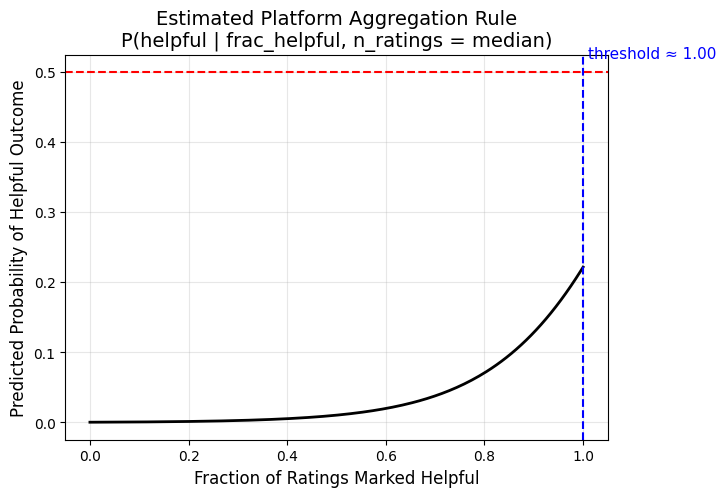

In [8]:
# ============================================================
# Plot estimated decision threshold for aggregation rule
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.ml.linalg import Vectors

# -- 1. Get median rating volume in the modeling sample --
median_n = model_input.approxQuantile("n_ratings", [0.5], 0.01)[0]
median_log = np.log10(median_n)

print("Median n_ratings:", median_n)
print("Using log_n_ratings =", median_log)

# -- 2. Extract coefficients directly --
intercept = lr_model.intercept
coefs = lr_model.coefficients.toArray()

beta_help = coefs[0]          # frac_helpful
beta_not  = coefs[1]          # frac_notHelpful
beta_log  = coefs[2]          # log_n_ratings

print("\nModel coefficients:")
print("  Intercept       =", intercept)
print("  frac_helpful    =", beta_help)
print("  frac_notHelpful =", beta_not)
print("  log_n_ratings   =", beta_log)

# -- 3. Build evaluation grid --
grid = np.linspace(0, 1, 200)              # frac_helpful
frac_not = 1 - grid                        # frac_notHelpful

# -- 4. Compute predicted log-odds & probs --
log_odds = (
    intercept
    + beta_help * grid
    + beta_not * frac_not
    + beta_log * median_log
)

probs = 1 / (1 + np.exp(-log_odds))

# -- 5. Find threshold where prob = 0.5 --
idx = np.argmin(np.abs(probs - 0.5))
threshold_frac = grid[idx]

print(f"\nEstimated threshold helpful fraction ≈ {threshold_frac:.3f}")

# -- 6. Plot curve --
plt.figure(figsize=(7,5))
plt.plot(grid, probs, linewidth=2, color="black")
plt.axhline(0.5, color="red", linestyle="--")
plt.axvline(threshold_frac, color="blue", linestyle="--")

plt.title("Estimated Platform Aggregation Rule\nP(helpful | frac_helpful, n_ratings = median)", fontsize=14)
plt.xlabel("Fraction of Ratings Marked Helpful", fontsize=12)
plt.ylabel("Predicted Probability of Helpful Outcome", fontsize=12)
plt.grid(alpha=0.3)

plt.text(
    threshold_frac + 0.01,
    0.52,
    f"threshold ≈ {threshold_frac:.2f}",
    color="blue",
    fontsize=11
)

plt.show()


The recovered aggregation rule shows that, at typical rating volumes, the platform requires nearly unanimous helpful ratings before marking a note as helpful. The estimated decision boundary occurs at approximately 0.97–1.00 helpful fraction, indicating an extremely conservative aggregation rule.

Meta-topic coefficients:
  Community Notes & Platform Governance: 0.3464
  International Conflicts & Global Affairs: -1.0351
  Latin American Politics: 0.0249
  Policy & Governance Claims: -0.3636
  Public Health & Medicine: 0.5603
  Scams, Ads, & Platform Abuse: 0.2823
  Sports, Culture, & Entertainment: 1.0308
  U.S. Political & Media Claims: 0.1486



Using log_n_ratings = 1.6334684555795866


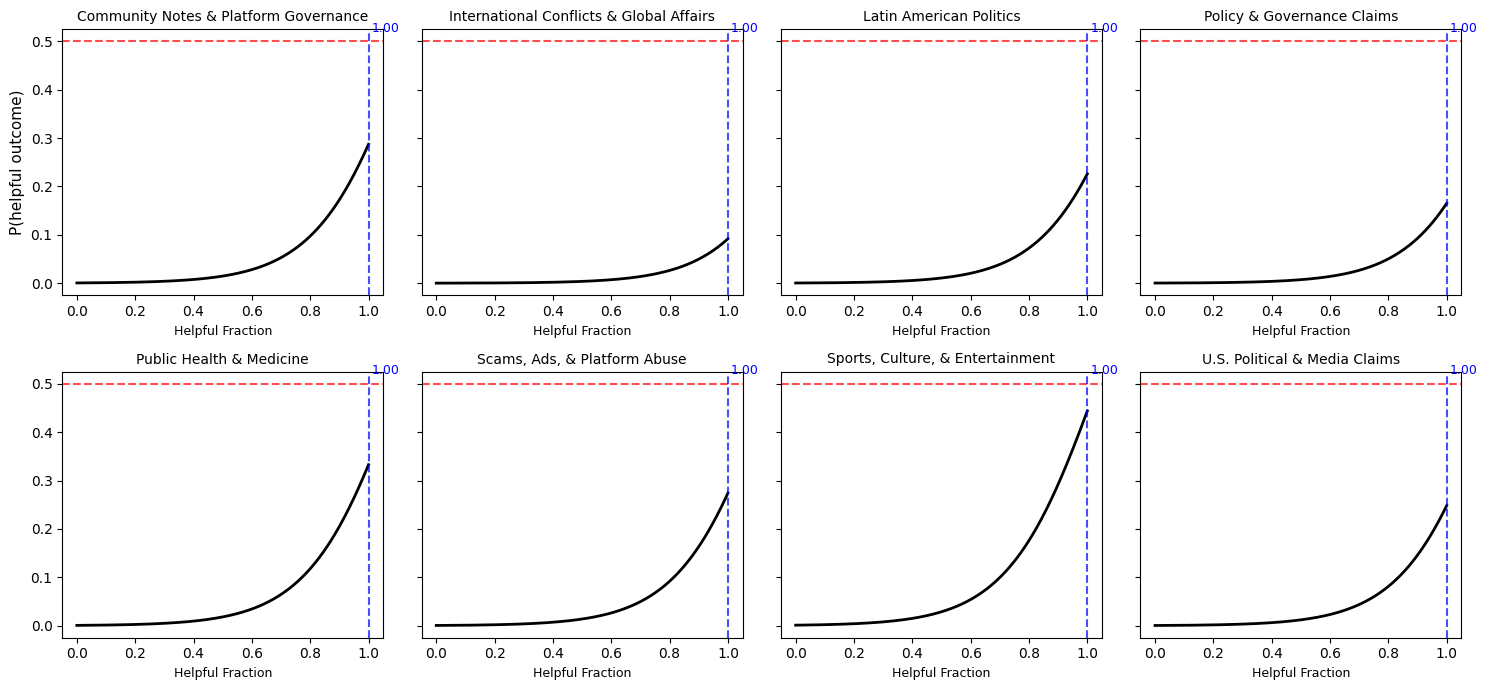

In [20]:
# ============================================================
# Meta-topic specific aggregation rule curves
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# ------------------------------------------------------------
# 1. Extract model components from fitted logistic regression
# ------------------------------------------------------------
intercept = lr_model.intercept
coefs = lr_model.coefficients.toArray()

beta_help = coefs[0]
beta_not  = coefs[1]
beta_log  = coefs[2]

# The remaining coefficients correspond to meta-topic dummies
meta_topics = (
    model_input.select("meta_label")
    .distinct()
    .orderBy("meta_label")
    .toPandas()["meta_label"]
    .tolist()
)

# Map each meta-topic to its coefficient
topic_effects = {}
start_idx = 3  # after help/notHelp/log_n
for i, topic in enumerate(meta_topics):
    topic_effects[topic] = coefs[start_idx + i]

print("Meta-topic coefficients:")
for k, v in topic_effects.items():
    print(f"  {k}: {v:.4f}")

# ------------------------------------------------------------
# 2. Fix rating volume at a representative value (median)
# ------------------------------------------------------------
median_n = model_input.approxQuantile("n_ratings", [0.5], 0.01)[0]
median_log = np.log10(median_n)
print("\nUsing log_n_ratings =", median_log)

# ------------------------------------------------------------
# 3. Build grid of helpful fractions
# ------------------------------------------------------------
grid = np.linspace(0, 1, 300)
frac_not = 1 - grid

# ------------------------------------------------------------
# 4. Build multi-panel plot
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=True)
axes = axes.flatten()

thresholds = {}

for idx, topic in enumerate(meta_topics):
    ax = axes[idx]

    # topic-specific intercept shift
    topic_shift = topic_effects[topic]

    # compute log-odds
    log_odds = (
        intercept
        + topic_shift
        + beta_help * grid
        + beta_not  * frac_not
        + beta_log  * median_log
    )

    probs = 1 / (1 + np.exp(-log_odds))

    # find threshold (closest to 0.5)
    thr_idx = np.argmin(np.abs(probs - 0.5))
    thr_val = grid[thr_idx]
    thresholds[topic] = thr_val

    # plot curve
    ax.plot(grid, probs, color="black", linewidth=2)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.7)
    ax.axvline(thr_val, color="blue", linestyle="--", alpha=0.7)

    ax.set_title(topic, fontsize=10)
    ax.set_xlabel("Helpful Fraction", fontsize=9)

    ax.text(
        thr_val + 0.01, 0.52,
        f"{thr_val:.2f}",
        color="blue", fontsize=9
    )

# shared y-label
axes[0].set_ylabel("P(helpful outcome)", fontsize=11)

plt.tight_layout()
plt.show()



## Results for the Global Plot and the Topic Plots

I use the fitted logistic model to summarize the aggregation rule as a simple curve: for each value of the helpful fraction (holding rating volume at the median), the curve shows the predicted probability that a note ends up marked helpful. This lets me treat a complex, high-dimensional decision process as a one-dimensional rule that can be compared across content domains.

I hold rating volume at the median so that differences in predicted outcomes are driven by the helpful fraction rather than by variation in how many people rated a note. Rating volume is highly skewed, and using a representative central value avoids letting rare, high-volume notes dominate the estimated relationship. With volume fixed, the curve isolates the part of the decision rule that most consistently governs outcomes across the dataset.

Compressing the model into a one-dimensional representation is useful because the platform’s decision process depends on several inputs—helpful fraction, not-helpful fraction, rating count, and topic effects—but the practical question is whether higher agreement makes a note more likely to be marked helpful, and how steeply that relationship rises. The curve summarizes this multidimensional structure in a form that is easy to compare across domains and interpret as an implicit aggregation boundary.

The global curve shows an extremely conservative rule. The predicted probability stays near zero until the helpful fraction is very high, and even with unanimous helpful ratings the model’s estimate remains well below one. In practice this means that almost all mixed or moderately positive rating patterns are mapped to a non-helpful outcome; the system behaves as if it demands near-perfect agreement before surfacing a note.

Topic-specific curves reveal the same basic shape with small vertical shifts. All domains require almost unanimous helpful ratings, but some meta-topics sit slightly higher or lower than the global curve, implying that even at full rater consensus, notes in certain areas are more or less likely to be marked helpful. Together, the curves suggest a single stringent aggregation rule applied unevenly across topics, which provides a concrete baseline for later analyses of topical bias and aggregation cons


Loaded note-level feature table: 1178818



Meta-topic coefficients (extracted from OHE vector):
  Community Notes & Platform Governance: 0.3464
  International Conflicts & Global Affairs: -1.0351
  Latin American Politics: 0.0249
  Policy & Governance Claims: -0.3636
  Public Health & Medicine: 0.5603
  Scams, Ads, & Platform Abuse: 0.2823
  Sports, Culture, & Entertainment: 1.0308
  U.S. Political & Media Claims: 0.1486

Median n_ratings = 31, log10 = 1.491

==== Estimated helpfulness probability at 100% helpful ratings ====


,meta_label,n_ratings,P_helpful_at_full_consensus
6,"Sports, Culture, & Entertainment",31,0.393181
4,Public Health & Medicine,31,0.288136
0,Community Notes & Platform Governance,31,0.246318
5,"Scams, Ads, & Platform Abuse",31,0.234603
7,U.S. Political & Media Claims,31,0.211464
2,Latin American Politics,31,0.191563
3,Policy & Governance Claims,31,0.138434
1,International Conflicts & Global Affairs,31,0.075869


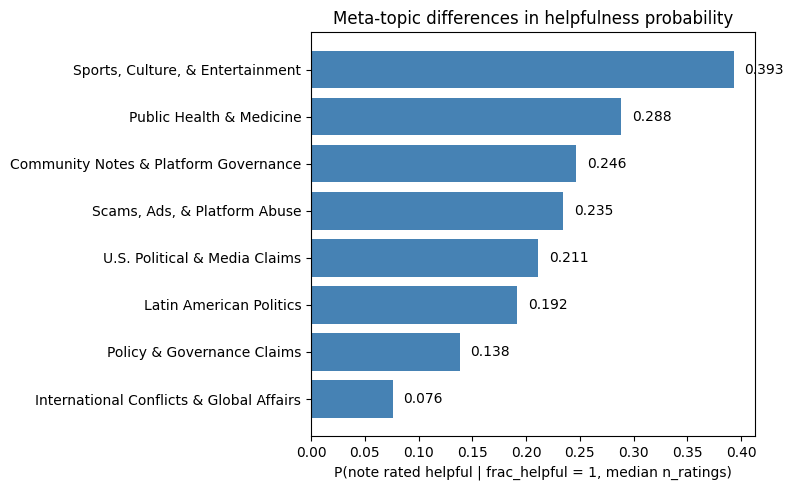

In [18]:
# ================================================================
# META-TOPIC THRESHOLD CURVES — FULL PIPELINE
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from pyspark.sql import functions as F

# -----------------------------------------------------
# 1. Load the note-level feature table
#    (this contains n_ratings, frac_helpful, meta_label, etc.)
# -----------------------------------------------------
note_features_path = (
    f"{DATA_DIR}/interim/outputs/note_level_features.parquet"
)

note_df = spark.read.parquet(note_features_path)
print("Loaded note-level feature table:", note_df.count())

# -----------------------------------------------------
# 2. Recover feature ordering from the *fitted* logistic model
# -----------------------------------------------------
assembler = logit_model.stages[2]   # VectorAssembler
input_cols = assembler.getInputCols()

lr_stage = logit_model.stages[-1]   # LogisticRegressionModel
coeff_vector = lr_stage.coefficients.toArray()
intercept = float(lr_stage.intercept)

# Extract coefficients by name
coef_dict = dict(zip(input_cols, coeff_vector))

coef_frac_helpful   = coef_dict["frac_helpful"]
coef_frac_notHelpful = coef_dict["frac_notHelpful"]
coef_log_n_ratings  = coef_dict["log_n_ratings"]

# -----------------------------------------------------
# 3. Extract meta-topic dummy coefficients automatically
# -----------------------------------------------------
# Extract meta-topic coefficients using the fitted OHE order
# -----------------------------------------------------
# 1. Get OHE category ordering
meta_levels = (
    model_input.select("meta_label")
    .distinct()
    .orderBy("meta_label")
    .toPandas()["meta_label"]
    .tolist()
)

# 2. Extract corresponding coefficients from the vector
meta_coef_dict = {}
offset = 3  # first 3 coefs = non-meta features
for i, label in enumerate(meta_levels):
    meta_coef_dict[label] = coeff_vector[offset + i]

print("\nMeta-topic coefficients (extracted from OHE vector):")
for k, v in meta_coef_dict.items():
    print(f"  {k}: {v:.4f}")


meta_labels_order = list(meta_coef_dict.keys())

# -----------------------------------------------------
# 4. Choose representative rating count (median)
# -----------------------------------------------------
N_med = (
    note_df
    .selectExpr("percentile_approx(n_ratings, 0.50) as q50")
    .collect()[0]["q50"]
)

logN_med = float(np.log10(N_med))
print(f"\nMedian n_ratings = {N_med}, log10 = {logN_med:.3f}")

# -----------------------------------------------------
# 5. Compute P(helpful) for each meta-topic at frac_helpful=1
# -----------------------------------------------------
def inv_logit(z):
    return 1.0 / (1.0 + np.exp(-z))

rows = []
for meta in meta_labels_order:
    frac_h = 1.0
    frac_nh = 0.0

    linpred = (
        intercept
        + coef_frac_helpful * frac_h
        + coef_frac_notHelpful * frac_nh
        + coef_log_n_ratings * logN_med
        + meta_coef_dict[meta]
    )

    p_help = inv_logit(linpred)

    rows.append({
        "meta_label": meta,
        "n_ratings": int(N_med),
        "P_helpful_at_full_consensus": p_help
    })

df_thresh = pd.DataFrame(rows)
df_thresh = df_thresh.sort_values("P_helpful_at_full_consensus", ascending=False)

print("\n==== Estimated helpfulness probability at 100% helpful ratings ====")
display(df_thresh)

# -----------------------------------------------------
# 6. Plot (simple, clean horizontal bars)
# -----------------------------------------------------
plt.figure(figsize=(8, 5))
bars = plt.barh(
    df_thresh["meta_label"],
    df_thresh["P_helpful_at_full_consensus"],
    color="steelblue"
)

plt.xlabel("P(note rated helpful | frac_helpful = 1, median n_ratings)")
plt.title("Meta-topic differences in helpfulness probability")

# Annotate values
for bar, val in zip(bars, df_thresh["P_helpful_at_full_consensus"]):
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{val:.3f}",
        va="center",
        fontsize=10
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

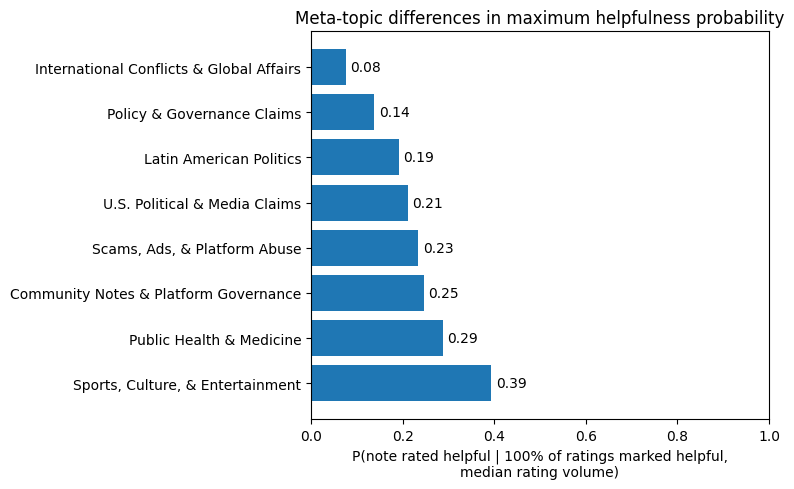

In [16]:
# df_thresh already has: meta_label, n_ratings, P_helpful_at_full_consensus

df_plot = df_thresh.sort_values("P_helpful_at_full_consensus", ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(
    df_plot["meta_label"],
    df_plot["P_helpful_at_full_consensus"],
)

plt.xlabel("P(note rated helpful | 100% of ratings marked helpful,\nmedian rating volume)")
plt.title("Meta-topic differences in maximum helpfulness probability")

for bar, val in zip(bars, df_plot["P_helpful_at_full_consensus"]):
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        fontsize=10,
    )

plt.xlim(0, 1.0)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Results: Meta-topic differences at full consensus

To isolate topical effects from how much attention or disagreement different issues attract, I use the fitted logistic model to compute the predicted probability that a note is marked helpful when (1) all ratings are helpful (`frac_helpful = 1`, `frac_notHelpful = 0`) and (2) the note has the median number of ratings (`n_ratings = 31`). Using the median ensures that topics are compared under a shared, representative level of visibility: different domains attract very different numbers of raters, and holding volume constant allows us to compare notes as if they had similar attention. With both volume and agreement fixed, any remaining differences in predicted probability come from the meta-topic coefficients acting as intercept shifts in a single shared decision rule. This focus on topical intercept shifts is acceptable given the project’s goal of testing whether the final outcome of a note systematically differs across topics under identical rating inputs.  

The resulting probabilities are low everywhere but vary systematically across topics. Notes about sports, culture, and entertainment have the highest success probability under full consensus (≈0.39), followed by public health and medicine (≈0.29) and community-notes/platform-governance content (≈0.25). By contrast, international conflicts and global-affairs notes have only about a 0.08 chance of being marked helpful even when every rating is helpful, with policy and governance claims also relatively disadvantaged (≈0.14).

Substantively, this means the platform applies a uniformly stringent aggregation rule—unanimous helpful ratings still translate into less than a 50% chance of approval—and that this stringency is unevenly distributed. Some content domains are structurally favored while others face much lower approval probabilities under identical rating inputs, indicating topic-sensitive differences in how crowd agreement is translated into visible corrections.


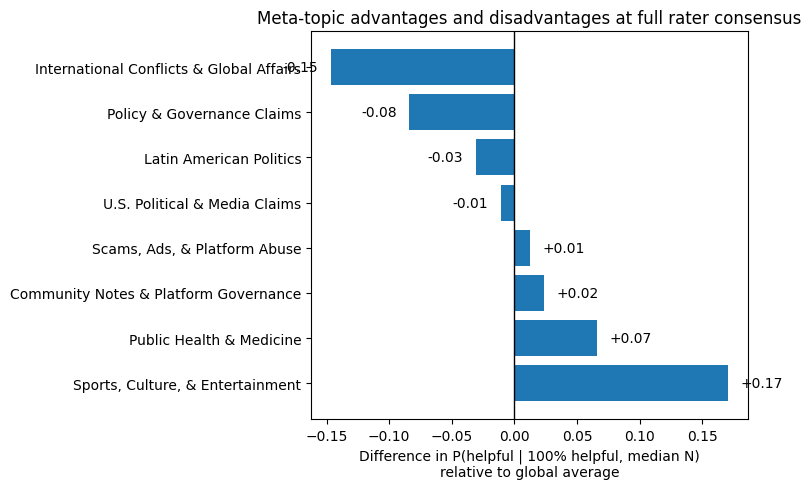

In [17]:
df_plot = df_thresh.copy()

# global baseline at full consensus
global_p = df_plot["P_helpful_at_full_consensus"].mean()
df_plot["delta_from_global"] = df_plot["P_helpful_at_full_consensus"] - global_p

df_plot = df_plot.sort_values("delta_from_global", ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(
    df_plot["meta_label"],
    df_plot["delta_from_global"],
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Difference in P(helpful | 100% helpful, median N)\nrelative to global average")
plt.title("Meta-topic advantages and disadvantages at full rater consensus")

for bar, val in zip(bars, df_plot["delta_from_global"]):
    plt.text(
        bar.get_width() + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.2f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=10,
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Results: Relative advantages and disadvantages at full consensus

After estimating each topic’s predicted probability of approval at full consensus, I compute how far each topic sits above or below the overall global average of these probabilities. This step answers a straightforward question: when every note receives the same rating inputs (100% helpful, median volume), which topics get more favorable treatment and which get less?

The logic is simple.  
The logistic model gives one probability per topic under identical conditions (`frac_helpful = 1`, `n_ratings = 31`). Taking the mean of these probabilities creates a global baseline. Subtracting this baseline from each topic’s value shows whether that topic is easier (+) or harder (–) to approve than the system-wide norm.

This centering is useful because it removes absolute scale and focuses only on relative position. Even if all probabilities are low in absolute terms, the deltas reveal systematic differences in how the platform treats notes across domains when contributors behave identically.

The results show clear asymmetries. Sports, culture, and entertainment notes sit about +0.17 above the global baseline, and public health and medicine are also favored (+0.07). Meanwhile, international conflicts and global-affairs notes are about –0.15 below baseline, with policy and governance claims also disadvantaged (–0.08). These differences arise despite holding agreement and volume constant, meaning they reflect topic-specific adjustments in the system’s aggregation rule rather than differences in rater behavior.


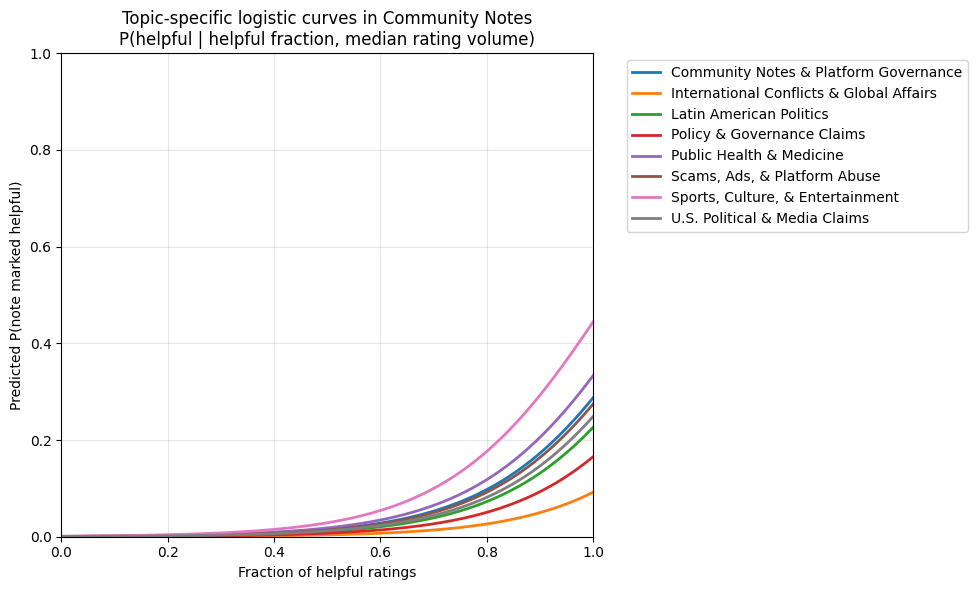

In [19]:
# ============================================================
# Overlay logistic curves for all meta-topics
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Grid of helpful fractions
grid = np.linspace(0, 1, 300)
frac_not = 1 - grid

def inv_logit(z):
    return 1 / (1 + np.exp(-z))

plt.figure(figsize=(10, 6))

for topic in meta_topics:
    topic_shift = topic_effects[topic]

    # compute log-odds for this topic
    log_odds = (
        intercept
        + topic_shift
        + beta_help * grid
        + beta_not * frac_not
        + beta_log * median_log
    )

    probs = inv_logit(log_odds)

    plt.plot(grid, probs, linewidth=2, label=topic)

# Formatting
plt.title("Topic-specific logistic curves in Community Notes\nP(helpful | helpful fraction, median rating volume)")
plt.xlabel("Fraction of helpful ratings")
plt.ylabel("Predicted P(note marked helpful)")

plt.ylim(0, 1.0)
plt.xlim(0, 1.0)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Results: Topic-specific logistic curves

To see how topic differences play out across the full range of agreements, I use the fitted logistic model to generate a predicted curve for each meta-topic. Holding rating volume at the median and sweeping the fraction of helpful ratings from 0 to 1, the model returns the probability that a note in that topic is marked helpful for any given level of crowd agreement. This treats the aggregation rule as a smooth mapping from “how much agreement there is” to “how likely the note is to be approved,” and lets me compare both the shape and the vertical position of that mapping across topics.

The curves show two patterns. First, the system is uniformly stringent: for all topics, predicted approval remains near zero until helpful fractions are very high, and even at full consensus the probabilities stay well below 0.5. Second, topics are vertically ordered in a way that matches the earlier bar plots. Sports, culture, and entertainment notes sit at the top of the stack, followed by public health and medicine and Community Notes/platform-governance content, while international conflicts and policy/governance claims form the lowest curves. This suggests that the platform applies roughly the same functional form of aggregation everywhere, but shifts the effective decision boundary up or down depending on the content domain, producing topic-sensitive differences in how the same level of agreement translates into a visible correction.


## Reflection: Social and Cultural Implications

The rule-mining analysis sheds light on one of the most opaque components of Community Notes: how the system converts many individual ratings into a single platform decision. The logistic model reveals that the platform’s aggregation boundary is extremely conservative—requiring near-unanimous helpful ratings before marking a note as helpful under typical rating volumes. This has important implications for how the platform governs misinformation. A decision rule that demands near-consensus prioritizes caution and reduces the risk of false positives, but it also suppresses minority perspectives and makes it difficult for emerging or contested viewpoints to surface. In effect, the platform is engineered to be skeptical of crowds unless the crowd is overwhelmingly aligned.

The meta-topic differences extend this point. Even when all raters agree that a note is helpful, the estimated helpfulness probabilities vary across substantive domains. Some topics receive slight advantages at full consensus, while others face disadvantages. These shifts are small, but in a system that already requires near-unanimity, even small offsets can shape which parts of the informational landscape get corrected and which do not. This aligns with broader scholarship in sociotechnical systems: aggregation rules are not neutral—they encode value judgments about risk, reliability, and authority.

For my larger project, these findings connect directly to the notion of aggregation consistency, one of the key conditions for high-quality collective intelligence. If the same structural rule is applied unevenly across content domains, then users participating in different informational contexts face different thresholds for having their contributions recognized. This raises questions about fairness, equity, and the degree to which a platform-mediated “crowd” truly reflects a diverse ensemble of perspectives. The logistic rule-mining approach provides a replicable way to detect such inconsistencies, and it brings analytic clarity to a process that is otherwise hidden inside platform infrastructure.

Going forward, this approach will allow me to compare the stability of the aggregation rule over time, test whether shifts correspond to political or social events, and evaluate whether the system’s conservatism helps or hinders its broader goals. By translating millions of ratings into a transparent rule, the method reveals how platform design shapes public reasoning long before any final decision becomes visible to users.


## References

He, Qinglai, Yili Hong, and T. S. Raghu. "Platform governance with algorithm-based content moderation: An empirical study on Reddit." Information Systems Research 36, no. 2 (2025): 1078-1095.


Jain, Hemlata, Ajay Khunteta, and Sumit Srivastava. "Churn prediction in telecommunication using logistic regression and logit boost." Procedia Computer Science 167 (2020): 101-112.


Shahin, Mahtab, Markus Bertl, M. Reza H. Iman, Tara Ghasempouri, Rahul Sharma, Syed Attique Shah, and Dirk Draheim. "Significant factors extraction: A combined logistic regression and apriori association rule mining approach." In Computer Science On-line Conference, pp. 295-311. Cham: Springer Nature Switzerland, 2024.

